# (KNN) Lab 9
Student: Mehrali (24P-0500)
Course: AI Lab (AL2002)

## Experiment Section
Experiments based on the paper tissue training data from the manual.

In [1]:
import math

# Base training data from manual
training_data = [
    [7, 7, "Bad"],
    [7, 4, "Bad"],
    [3, 4, "Good"],
    [1, 4, "Good"]
]

def euclidean_distance(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total += diff * diff
    return math.sqrt(total)

def get_neighbors(training_data, new_point, k):
    distances = []
    for row in training_data:
        features = [row[0], row[1]]
        label = row[2]
        dist = euclidean_distance(new_point, features)
        distances.append([dist, label])

    # Bubble sort (as in manual)
    for i in range(len(distances)):
        for j in range(i + 1, len(distances)):
            if distances[j][0] < distances[i][0]:
                temp = distances[i]
                distances[i] = distances[j]
                distances[j] = temp

    neighbors = []
    for i in range(k):
        neighbors.append(distances[i])
    return neighbors

def classify(training_data, new_point, k):
    neighbors = get_neighbors(training_data, new_point, k)
    votes = {}
    for neighbor in neighbors:
        label = neighbor[1]
        if label in votes:
            votes[label] += 1
        else:
            votes[label] = 1

    best_label = None
    best_count = 0
    for label in votes:
        if votes[label] > best_count:
            best_count = votes[label]
            best_label = label
    return best_label

print("Experiment 1: Effect of k for point [3, 7]")
for k in [1, 3]:
    neighbors = get_neighbors(training_data, [3, 7], k)
    neighbor_labels = [n[1] for n in neighbors]
    prediction = classify(training_data, [3, 7], k)
    print(f"k={k}, Prediction={prediction}, Neighbor Labels={neighbor_labels}")

print("\nExperiment 2: More training data")
extended_data = training_data + [
    [3, 6, "Good"],
    [5, 5, "Bad"],
    [2, 8, "Good"],
    [8, 3, "Bad"]
]
for k in [3, 5]:
    prediction = classify(extended_data, [3, 7], k)
    print(f"k={k}, Prediction={prediction}")

print("\nExperiment 3: Classify multiple points (k=3)")
test_points = [[5, 6], [2, 3], [8, 8], [4, 5]]
for point in test_points:
    result = classify(extended_data, point, 3)
    print("Point:", point, "->", result)

Experiment 1: Effect of k for point [3, 7]
k=1, Prediction=Good, Neighbor Labels=['Good']
k=3, Prediction=Good, Neighbor Labels=['Good', 'Good', 'Bad']

Experiment 2: More training data
k=3, Prediction=Good
k=5, Prediction=Good

Experiment 3: Classify multiple points (k=3)
Point: [5, 6] -> Bad
Point: [2, 3] -> Good
Point: [8, 8] -> Bad
Point: [4, 5] -> Good


## Task 1
Scratch KNN on Iris dataset (complete TODO functions).

In [2]:
import math

# Iris training data (12 samples)
iris_training_data = [
    [5.1, 3.5, 1.4, 0.2, "Setosa"],
    [4.9, 3.0, 1.4, 0.2, "Setosa"],
    [5.0, 3.4, 1.5, 0.2, "Setosa"],
    [4.8, 3.1, 1.6, 0.2, "Setosa"],
    [7.0, 3.2, 4.7, 1.4, "Versicolor"],
    [6.4, 3.2, 4.5, 1.5, "Versicolor"],
    [5.5, 2.3, 4.0, 1.3, "Versicolor"],
    [6.5, 2.8, 4.6, 1.5, "Versicolor"],
    [6.3, 3.3, 6.0, 2.5, "Virginica"],
    [7.1, 3.0, 5.9, 2.1, "Virginica"],
    [6.5, 3.0, 5.8, 1.8, "Virginica"],
    [7.6, 3.0, 6.6, 2.1, "Virginica"]
]

def euclidean_distance_iris(point1, point2):
    total = 0
    for i in range(len(point1)):
        diff = point1[i] - point2[i]
        total += diff * diff
    return math.sqrt(total)

def classify_iris(training_data, new_point, k):
    distances = []
    for row in training_data:
        features = row[:-1]
        label = row[-1]
        dist = euclidean_distance_iris(new_point, features)
        distances.append([dist, label])

    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]

    votes = {}
    for neighbor in neighbors:
        label = neighbor[1]
        votes[label] = votes.get(label, 0) + 1

    best_label = max(votes, key=votes.get)
    return best_label

test_flowers = [
    [5.0, 3.3, 1.4, 0.2],
    [6.0, 2.7, 4.5, 1.5],
    [7.2, 3.2, 6.0, 1.8]
 ]

print("Length check (len(point1)):", len(test_flowers[0]))
print("Task 1 Predictions (k=3):")
for flower in test_flowers:
    result = classify_iris(iris_training_data, flower, 3)
    print("Flower:", flower, "-> Species:", result)

print("Bonus: k = 1, 3, 5")
for flower in test_flowers:
    pred_k1 = classify_iris(iris_training_data, flower, 1)
    pred_k3 = classify_iris(iris_training_data, flower, 3)
    pred_k5 = classify_iris(iris_training_data, flower, 5)
    print(f"Flower {flower} -> k=1:{pred_k1}, k=3:{pred_k3}, k=5:{pred_k5}")

Length check (len(point1)): 4
Task 1 Predictions (k=3):
Flower: [5.0, 3.3, 1.4, 0.2] -> Species: Setosa
Flower: [6.0, 2.7, 4.5, 1.5] -> Species: Versicolor
Flower: [7.2, 3.2, 6.0, 1.8] -> Species: Virginica
Bonus: k = 1, 3, 5
Flower [5.0, 3.3, 1.4, 0.2] -> k=1:Setosa, k=3:Setosa, k=5:Setosa
Flower [6.0, 2.7, 4.5, 1.5] -> k=1:Versicolor, k=3:Versicolor, k=5:Versicolor
Flower [7.2, 3.2, 6.0, 1.8] -> k=1:Virginica, k=3:Virginica, k=5:Virginica


## Task 2
Using Scikit-Learn on fruit_data_with_colors.csv

Accuracy scores by K:
K=1: 0.0000
K=2: 0.0000
K=3: 0.0000
K=4: 0.0000
K=5: 0.0000
K=6: 0.0000
K=7: 0.0000
K=8: 0.0000
K=9: 0.0000
K=10: 0.0000
Best K = 1, Best Accuracy = 0.0000


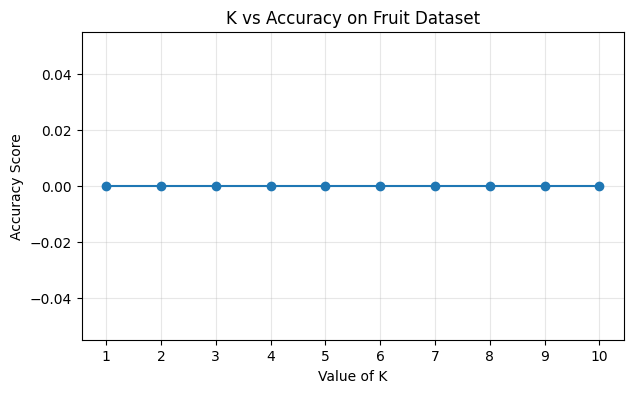

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Load the data
df = pd.read_csv('fruit_data_with_colors .csv')

# 2. Clean data
df = df.select_dtypes(exclude=['object'])
df = df.fillna(df.mean())

# 3. Split data (first 50 train, remaining test)
train_df = df.iloc[:50]
test_df = df.iloc[50:]

X_train = train_df.drop('fruit_label', axis=1)
y_train = train_df['fruit_label']
X_test = test_df.drop('fruit_label', axis=1)
y_test = test_df['fruit_label']

# 4 & 5. Model for K=1..10
k_values = list(range(1, 11))
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

best_score = max(scores)
best_k = k_values[scores.index(best_score)]
print('Accuracy scores by K:')
for k, s in zip(k_values, scores):
    print(f'K={k}: {s:.4f}')
print(f'Best K = {best_k}, Best Accuracy = {best_score:.4f}')

# Keep values for results
task2_best_k = best_k
task2_best_score = best_score

# 6. Plot
plt.figure(figsize=(7, 4))
plt.plot(k_values, scores, marker='o')
plt.xlabel('Value of K')
plt.ylabel('Accuracy Score')
plt.title('K vs Accuracy on Fruit Dataset')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

## Results
- Experiment 1, 2, 3 outputs are printed in the Experiment code cell.
- Task 1 predictions are printed in the Task 1 code cell.
- Task 2 accuracies for K=1 to K=10 and best K are printed in the Task 2 code cell.

## Graph
The graph of K vs Accuracy is shown in the Task 2 code output (matplotlib plot).

## Answers
1. **Checkpoint Question:** Which training point is closest to [3, 7]?
- The closest point is **[3, 4]** with distance **3.0**.

2. **Experiment 1 Question:** Does classification change for k=1 vs k=3? Why?
- No, it does not change. In both cases the predicted class is **Good** because the nearest points around [3, 7] are mostly Good.

3. **Experiment 2 Question:** Did results change after adding more data? Why?
- The result still stayed **Good** for both k=3 and k=5. The added Good points near [3, 7] kept the majority vote on Good.

4. **Task 1 Bonus:** Try k=1, k=3, k=5. Do results change?
- For these three test flowers, results did **not** change. Each flower kept the same species label for k=1, k=3, and k=5.

5. **Task 2 Question:** Which value of K gave the highest accuracy?
- Highest accuracy was **0.0000**. Since all values gave the same score, the first best value is **K = 1**.

6. **Task 2 Question:** Why did we drop text columns before training?
- KNN in sklearn needs numeric input to calculate distance. Text columns like fruit names are categorical strings, so they must be removed for this task.

7. **Task 2 Question:** What happens if we use all data for both train and test?
- The model will be tested on data it already saw during training, so accuracy can look fake-high. This is overfitting evaluation and does not show real performance on unseen data.

## Reflection
1. **Why is k usually chosen as an odd number?**  
Odd k helps avoid ties in binary classification problems. This makes the final vote clearer and gives one winning class.

2. **What if k is too small or too large?**  
If k is too small (like 1), model becomes sensitive to noise and can overfit. If k is too large, model becomes too general and may ignore useful local patterns.

3. **Why is KNN called a lazy learner? Advantage or disadvantage?**  
KNN is called lazy because it does not build a model during training; it stores data and does work at prediction time. This is simple and easy, but prediction can be slower on large datasets.

4. **Effect of feature scale differences and fix?**  
If one feature has a much bigger range, it dominates distance and can bias predictions. We should scale features (for example using normalization or standardization) before applying KNN.